<a href="https://colab.research.google.com/github/A8stern/PyAD_mobile_2025/blob/main/lab_7_kovalev.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа №7

**Выполнил: Ковалев Глеб К3341 367291**


## Описание датасета
Для анализа выбрана таблица **“European Football Injuries”** — набор данных о травмах/заболеваниях футболистов из **топ-5 европейских лиг** (Premier League, Bundesliga, La Liga, Serie A, Ligue 1) за сезоны **20/21–24/25**.

**Источник:** Kaggle, "European Football Injuries" : https://www.kaggle.com/datasets/sananmuzaffarov/european-football-injuries-2020-2025?resource=download

---

## Состав набора данных (поля таблицы)

- **Season** — сезон, к которому относится эпизод травмы (формат вроде `20/21`, `21/22` и т.д.).  
- **Injury** — тип травмы или причина отсутствия (например, *Knee injury*, *Corona virus*, *Ligament injury*).  
- **Days** — длительность отсутствия из-за травмы **в днях**, записанная строкой (например, `43 days`).  
- **Games missed** — количество матчей, пропущенных игроком за период данной травмы/отсутствия.  

- **injury_from_parsed** — дата начала травмы/отсутствия (дата, когда игрок выбыл), в строковом виде (обычно формат `M/D/YYYY`).  
- **injury_until_parsed** — дата окончания травмы/отсутствия (дата возвращения), в строковом виде (обычно формат `M/D/YYYY`).  

- **player_name** — имя и фамилия игрока (полное имя).  
- **player_age** — возраст игрока на момент травмы (в годах).  
- **player_position** — игровая позиция игрока (например, *Goalkeeper*, *Centre-Back* и т.п.).  

- **club** — клуб, за который выступал игрок на момент травмы.  
- **league** — лига, в которой выступает клуб (одна из “большой пятёрки”: *Premier League*, *Bundesliga*, *La Liga*, *Serie A*, *Ligue 1*).

---

## Гипотеза

- Связь возраста и длительности травм слабая.

##

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import mean_absolute_error, r2_score

In [2]:
data = pd.read_csv('football_injuries.csv')
data["Days"] = (
    data["Days"]
    .str.extract(r"(\d+)")
    .astype(float)
)
data.head()

,Season,Injury,Days,Games missed,injury_from_parsed,injury_until_parsed,player_name,player_age,player_position,club,league
0,20/21,Syndesmosis ligament tear,43.0,9,1/28/2021,3/11/2021,Alexander Nübel,24,Goalkeeper,Bayern Munich,Bundesliga
1,20/21,Knee injury,37.0,6,3/7/2021,4/12/2021,Ron-Thorben Hoffmann,22,Goalkeeper,Bayern Munich,Bundesliga
2,20/21,Corona virus,21.0,4,2/17/2021,3/9/2021,Benjamin Pavard,25,Centre-Back,Bayern Munich,Bundesliga
3,20/21,bruise,8.0,2,11/6/2020,11/13/2020,Benjamin Pavard,25,Centre-Back,Bayern Munich,Bundesliga
4,20/21,Ligament injury,22.0,2,7/26/2020,8/16/2020,Benjamin Pavard,25,Centre-Back,Bayern Munich,Bundesliga


## 1. Разделите данные на признаки (X) и целевую переменную (y).

In [3]:
X = data[["player_age"]]
y = data["Days"]

mask = y.notna()
X = X[mask]
y = y[mask]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (12482, 1)
X_test : (3121, 1)
y_train: (12482,)
y_test : (3121,)


## 2. Обучение двух простых моделей


In [4]:
models = {
    "LinearRegression": Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("model", LinearRegression())
    ]),
    "KNNRegressor(k=15)": Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", KNeighborsRegressor(n_neighbors=15))
    ]),
}

## 3. Оценка качества


In [5]:
results = {}

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    results[name] = {"MAE": mae, "R2": r2}

    print(f"\n{name}")
    print(f"MAE: {mae:.3f}")
    print(f"R² : {r2:.3f}")

best_name = sorted(results, key=lambda k: (-results[k]["R2"], results[k]["MAE"]))[0]
print("\nЛучшая модель по метрикам:", best_name)


LinearRegression
MAE: 30.152
R² : 0.001

KNNRegressor(k=15)
MAE: 28.527
R² : -0.040

Лучшая модель по метрикам: LinearRegression


## 4. Сформулируйте выводы

## Выводы по гипотезе (player_age → Days)

### Подтверждает ли модель гипотезу?
Гипотеза о том, что возраст игрока `player_age` не влияет на длительность восстановления `Days`, по результатам моделей подтверждается.

- **LinearRegression:** MAE = 30.152, R² = 0.001
  Это означает, что модель практически не объясняет вариацию `Days`.
- **KNNRegressor(k=15):** MAE = 28.527, R² = −0.040
  Отрицательный R² означает, что модель предсказывает хуже, чем простая константа (например, среднее/медиана).

Следовательно, **по одному признаку “возраст” длительность травмы предсказать нельзя**: связь либо очень слабая, либо сильно перекрывается другими факторами (тип травмы, позиция, клуб/лига, тяжесть, контекст и т.д.).

### Какие признаки оказались наиболее важными?
В данном эксперименте в качестве признака использовался только `player_age`, поэтому:
- **единственный “важный” признак — возраст**,  
- но по метрикам видно, что его вклад в предсказание `Days` минимален (R² около нуля), то есть возраст не является значимым предиктором длительности травмы в этой постановке задачи.

## 5. Визуализация данных

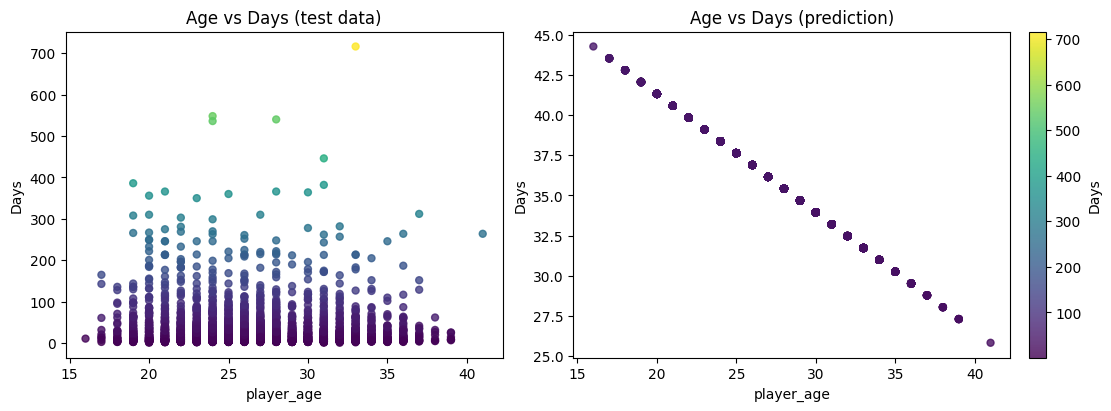

In [9]:
model_name = "LinearRegression"
pipe = models[model_name]

pipe.fit(X_train, y_train)
preds = pipe.predict(X_test)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

vmin = min(y_test.min(), preds.min())
vmax = max(y_test.max(), preds.max())

sc1 = ax1.scatter(
    X_test["player_age"], y_test,
    c=y_test, vmin=vmin, vmax=vmax, s=25, alpha=0.8
)
ax1.set_title("Age vs Days (test data)")
ax1.set_xlabel("player_age")
ax1.set_ylabel("Days")

sc2 = ax2.scatter(
    X_test["player_age"], preds,
    c=preds, vmin=vmin, vmax=vmax, s=25, alpha=0.8
)
ax2.set_title("Age vs Days (prediction)")
ax2.set_xlabel("player_age")
ax2.set_ylabel("Days")

cbar = fig.colorbar(sc2, ax=[ax1, ax2], fraction=0.04, pad=0.02)
cbar.set_label("Days")

plt.show()